In [22]:
import scipy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import networkx as nx
import simulator_fn
from simulator_fn import *

In [23]:
exec_idx = "CMM1"

match exec_idx:
    case "NM1":
        d = 1.5
    case "NM2":
        d = 1
    case "CM1":
        d = 1.5
    case "CM2":
        d = 2
    case "CM3":
        d = 2
    case _:
        d = 2

In [24]:
simulation_time = 100
plot_window = slice(60.0, 80.0)

In [25]:
best_solution = np.load(f"./solutions/best_solution-{exec_idx}.npy")
best_solution

array([[[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0., -18., -13.],
        [  0.,   0.,   0.,   0.,   0.,   8.,   0.,   8.],
        [  0.,   0.,   0.,   0.,   0.,   8.,  13.,   0.]],

       [[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   3.,   4.],
        [  0.,   0.,   0.,   0.,   0.,   4.,   0.,   3.],
        [  0.,   0.,   0.,   0.,   0.,   4.,   5.,   0.]]])

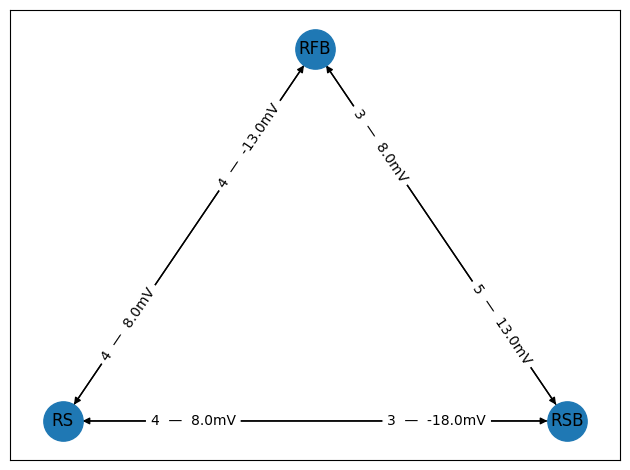

In [26]:
graph1 = nx.DiGraph(best_solution[0, -3:, -3:])
graph2 = nx.DiGraph(best_solution[1, -3:, -3:])

pos = nx.planar_layout(graph1)
nx.draw_networkx_nodes(graph1, pos, node_size=800)
nx.draw_networkx_edges(graph1, pos, node_size=800, arrows=True)
weight_labels_aux1 = nx.get_edge_attributes(graph1, 'weight')
weight_labels_aux2 = nx.get_edge_attributes(graph2, 'weight')
weight_labels = {}
for key, v in weight_labels_aux1.items():
    weight_labels[key] = f"{int(weight_labels_aux2[key])}  —  {weight_labels_aux1[key]}mV"
nx.draw_networkx_edge_labels(graph1, pos, edge_labels=weight_labels, label_pos=0.75)
nx.draw_networkx_labels(graph1, pos, labels={0: "RS", 1: "RSB", 2: "RFB"}, )
plt.tight_layout()
plt.show()

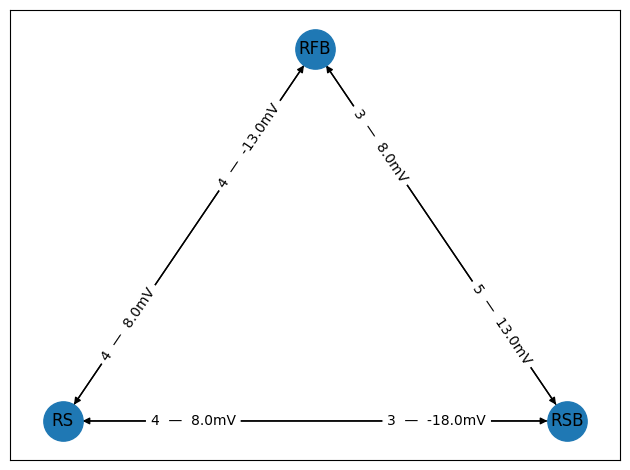

In [27]:
graph1 = nx.DiGraph(best_solution[0, -3:, -3:])
graph2 = nx.DiGraph(best_solution[1, -3:, -3:])

pos = nx.planar_layout(graph1)
nx.draw_networkx_nodes(graph1, pos, node_size=800)
nx.draw_networkx_edges(graph1, pos, node_size=800, arrows=True)
weight_labels_aux1 = nx.get_edge_attributes(graph1, 'weight')
weight_labels_aux2 = nx.get_edge_attributes(graph2, 'weight')
weight_labels = {}
for key, v in weight_labels_aux1.items():
    weight_labels[key] = f"{int(weight_labels_aux2[key])}  —  {weight_labels_aux1[key]}mV"
weight_labels_diag = {}
weight_labels_nodiag = weight_labels.copy()
if (0,0) in weight_labels: 
    weight_labels_diag[(0,0)] = weight_labels_nodiag.pop((0,0))
if (1,1) in weight_labels: 
    weight_labels_diag[(1,1)] = weight_labels_nodiag.pop((1,1))
if (2,2) in weight_labels: 
    weight_labels_diag[(2,2)] = weight_labels_nodiag.pop((2,2))

pos_diag = {k: v+np.array([0,.02]) for k,v in pos.items()}
nx.draw_networkx_edge_labels(graph1, pos, edge_labels=weight_labels_nodiag, label_pos=0.75)
nx.draw_networkx_edge_labels(graph1, pos_diag, edge_labels=weight_labels_diag, label_pos=0.75, clip_on=False, verticalalignment="bottom")

nx.draw_networkx_labels(graph1, pos, labels={0: "RS", 1: "RSB", 2: "RFB"}, )
plt.tight_layout()
plt.show()


In [28]:
np.load(f"./solutions/population-{exec_idx}.npy")[:5]

array([[  0., -18., -13.,   8.,   0.,   8.,   8.,  13.,   0.,   3.,   3.,
          4.,   4.,   4.,   3.,   4.,   5.,   4.],
       [-13., -18., -18.,   0.,   0.,   8.,  13.,   0.,   8.,   3.,   4.,
          3.,   3.,   5.,   3.,   5.,   1.,   2.],
       [-13., -13., -18.,   0.,  13.,   8.,  13.,  13.,   0.,   3.,   3.,
          5.,   5.,   3.,   4.,   3.,   5.,   4.],
       [  0.,   0.,  -8.,   0.,  13.,   0.,  13.,  13.,   8.,   3.,   3.,
          5.,   3.,   4.,   4.,   4.,   4.,   3.],
       [  0.,   0., -18.,   0.,   0.,   8.,  13.,  13.,   0.,   4.,   4.,
          5.,   3.,   3.,   3.,   4.,   5.,   4.]])

time simulator: 3.6149215698242188s
time metrics: 0.0038673877716064453s
{'Freq': 0.16598887874512405, 'Freq_naive': 0.09666972787471603, 'N_dead_neurons': 0, 'CV': 0.5870631157550222}


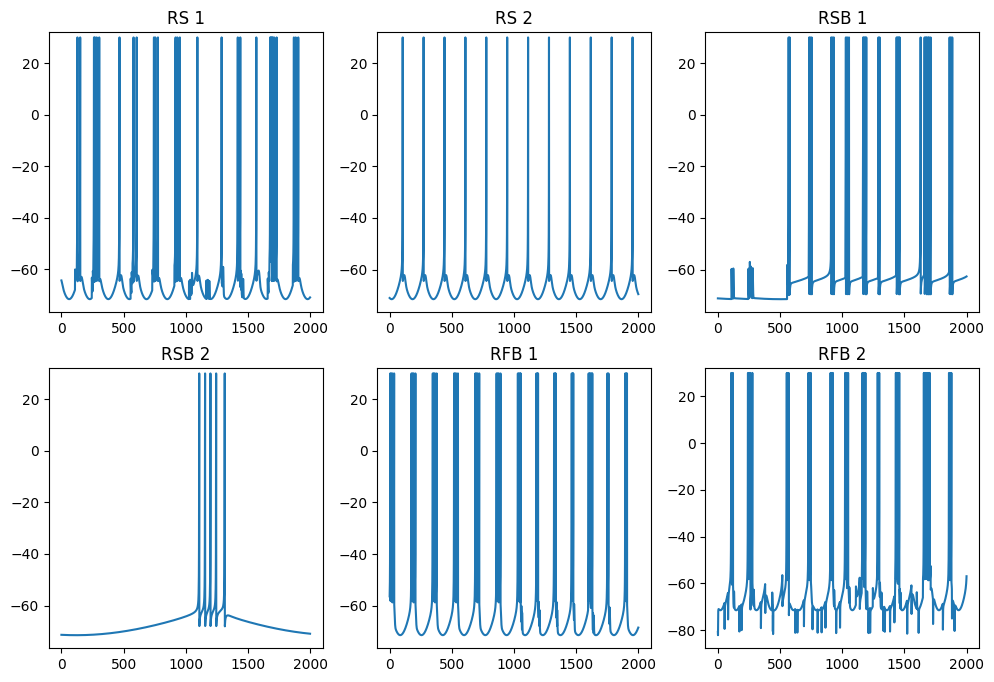

In [29]:
neuron_amounts = (0, 0, 0, 0, 0, 12, 6, 2)
adj_matrix = best_solution[0]
conn_matrix = best_solution[1]

t0 = time.time()
sim, volt = run_simulator(adj_matrix, conn_matrix, simulation_time=simulation_time, neuron_amounts=neuron_amounts, record_volt=True)
t1 = time.time()
print(f"time simulator: {t1 - t0}s")

t0 = time.time()
metrics = simulator_fn.get_metrics(sim, simulation_time=simulation_time, burst_thesh=0.02)
t1 = time.time()
print(f"time metrics: {t1 - t0}s")

print(metrics)

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax_flat = ax.flatten()

window = slice(2000,4000)
ax[0, 0].plot(volt[0, window])
ax[0, 1].plot(volt[1, window])
ax[0, 2].plot(volt[14, window])
ax[1, 0].plot(volt[15, window])
ax[1, 1].plot(volt[18, window])
ax[1, 2].plot(volt[19, window])

ax[0, 0].set(title=f"RS 1", ylim=(None, 32))
ax[0, 1].set(title=f"RS 2", ylim=(None, 32))
ax[0, 2].set(title=f"RSB 1", ylim=(None, 32))
ax[1, 0].set(title=f"RSB 2", ylim=(None, 32))
ax[1, 1].set(title=f"RFB 1", ylim=(None, 32))
ax[1, 2].set(title=f"RFB 2", ylim=(None, 32))

plt.show()

In [30]:
n_idx = 0

872


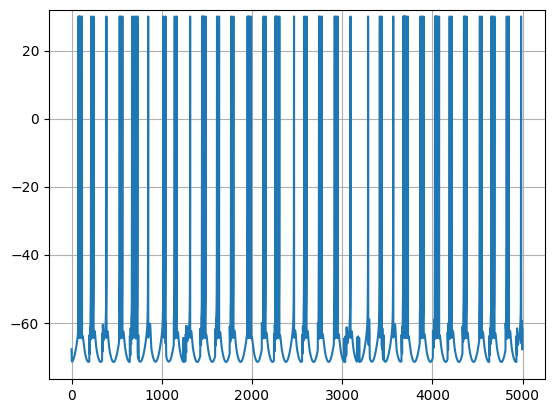

In [31]:
print(np.count_nonzero(np.diff(sim[n_idx]) > 0.02))
plt.plot(volt[n_idx, :5000])
plt.ylim((None, 32))
plt.grid()
plt.show()
n_idx = (n_idx+1) % len(volt)

1 0.16799999999999216 0.16800000000000637


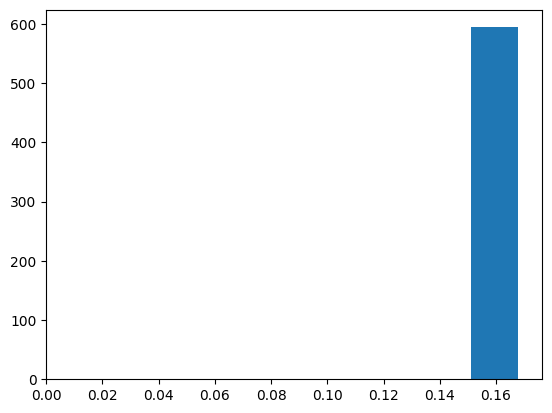

In [32]:
diff_times = np.diff(sim[n_idx])
while len(diff_times) < 1:
    n_idx = (n_idx+1) % len(volt)
    diff_times = np.diff(sim[n_idx])

print(n_idx, min(diff_times), max(diff_times))
plt.hist(np.concatenate((diff_times, [0])))
plt.xlim((0, None))

n_idx = (n_idx+1) % len(volt)

In [33]:
neuron_type_names = ["ISe", "ISi", "ISB", "IFB", "A", "RS", "RSB", "RFB"]
neuron_names = []
for type_name, type_amount in zip(neuron_type_names, neuron_amounts):
    neuron_names += [f"{i+1:2d} {type_name:3}" for i in range(type_amount)]
    
neuron_names

[' 1 RS ',
 ' 2 RS ',
 ' 3 RS ',
 ' 4 RS ',
 ' 5 RS ',
 ' 6 RS ',
 ' 7 RS ',
 ' 8 RS ',
 ' 9 RS ',
 '10 RS ',
 '11 RS ',
 '12 RS ',
 ' 1 RSB',
 ' 2 RSB',
 ' 3 RSB',
 ' 4 RSB',
 ' 5 RSB',
 ' 6 RSB',
 ' 1 RFB',
 ' 2 RFB']

/tmp/ipykernel_677303/584479695.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(


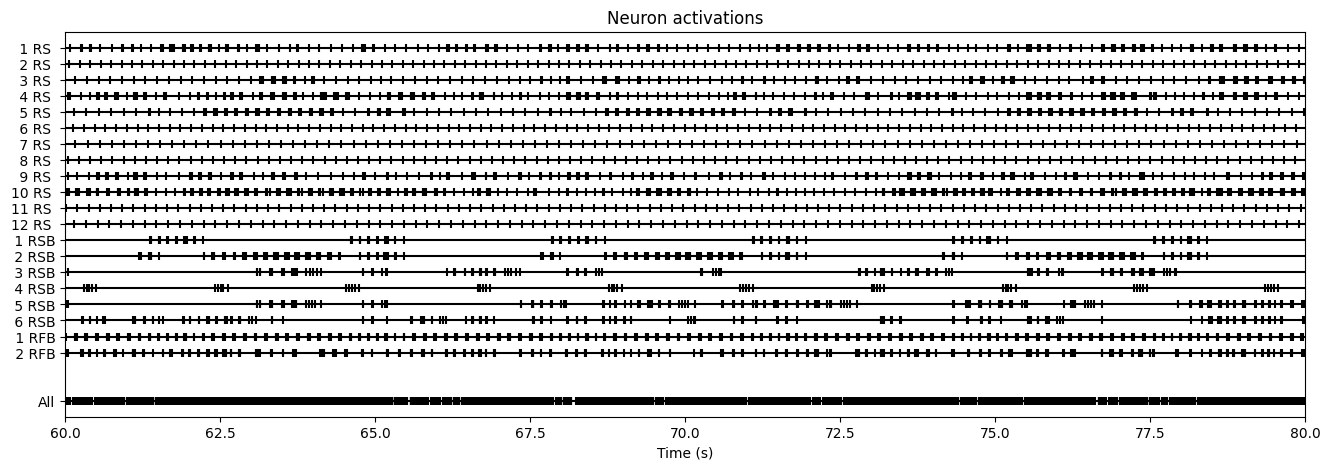

In [34]:
fig, ax = plt.subplots(1,1, figsize=(16,5))

voffset = 3
yticks = len(sim) - np.arange(len(sim)) + voffset
yticks = list(yticks) + [1]

ax.axhline(1, color='k')
for idx, sim_n in enumerate(sim):
    h = len(sim) - idx + voffset
    sim_n_arr = np.asarray(sim_n)
    sim_n_arr = sim_n_arr[(sim_n_arr > plot_window.start) | (sim_n_arr < plot_window.stop)]
    ax.axhline(h, color='k')
    ax.scatter(sim_n_arr, np.full_like(sim_n_arr, h), marker="|", color="k")
    ax.scatter(sim_n_arr, np.full_like(sim_n_arr, 1), marker="|", color="k")
    
ax.set(
    xlim=(plot_window.start, plot_window.stop),
    xlabel="Time (s)",
    ylim=(0, len(sim)+voffset+1),
    title="Neuron activations",
    yticklabels=neuron_names + ["All"],
    yticks=yticks
)
plt.show()

# Old frequency calculation

0.12


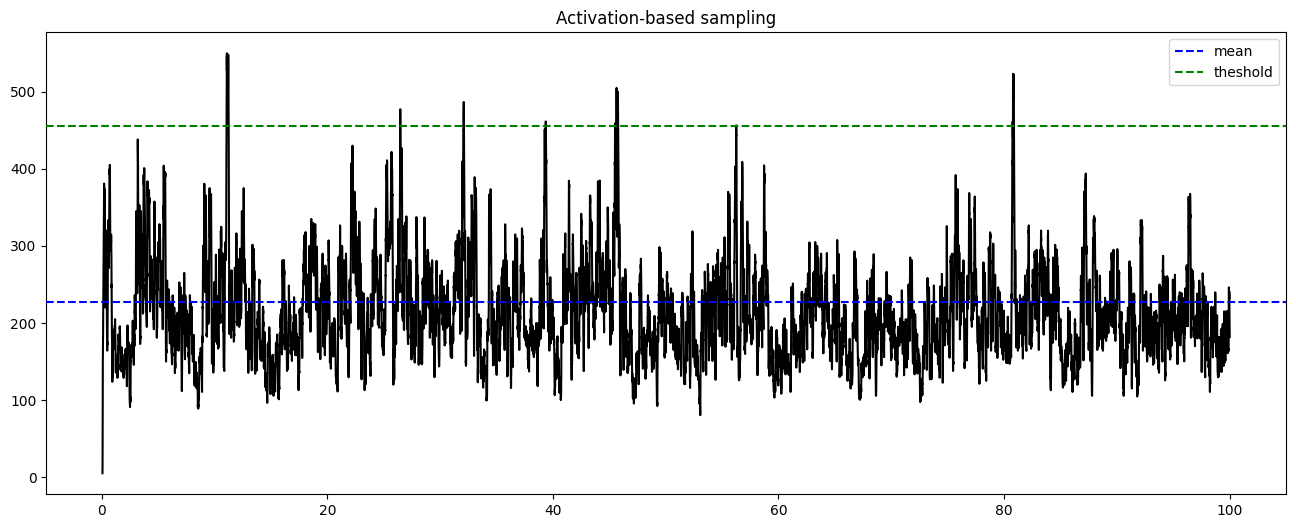

In [35]:
collapsed_sim = np.asarray(sorted(sum(sim, start=[])))
freq_ts = calculate_frequency(sim, simulation_time=simulation_time, bin_size=0.2, return_counts=False)
signal_mean = sp.ndimage.uniform_filter1d(freq_ts, 7)

# signal_mean = sp.ndimage.uniform_filter1d(freq_ts, window_len, mode="mirror", cval=rolling_mean.mean())
# signal_mean = np.median(freq_ts)
signal_mean = np.mean(freq_ts)

# signal_offset = np.std(freq_ts)
signal_offset = np.mean(freq_ts)/d * (d-1)

print(count_peaks_mean(freq_ts, d=d)/simulation_time)

fig, ax = plt.subplots(1,1, figsize=(16,6))
plt.plot(collapsed_sim, freq_ts, color='k')
# plt.axhline(freq_ts.mean(), c="blue", ls="--", label="mean", zorder=-10)
# plt.axhline(freq_ts.mean() + d*freq_ts.std(), c="green", ls="--", label="threshold", zorder=-10)
# plt.axhline(d*freq_ts.mean(), c="green", ls="--", label="threshold", zorder=-10)
if np.asarray(signal_mean).size == 1:
    plt.axhline(signal_mean, c="blue", ls="--", label="mean", zorder=10)
    plt.axhline(signal_mean + d*signal_offset, c="green", ls="--", label="theshold", zorder=10)
else:
    plt.plot(collapsed_sim, signal_mean, c="blue", ls="--", label="mean", zorder=10)
    plt.plot(collapsed_sim, signal_mean + d*signal_offset, c="green", ls="--", label="theshold", zorder=10)

plt.title("Activation-based sampling")
plt.legend()
plt.show()

60.0
80.0


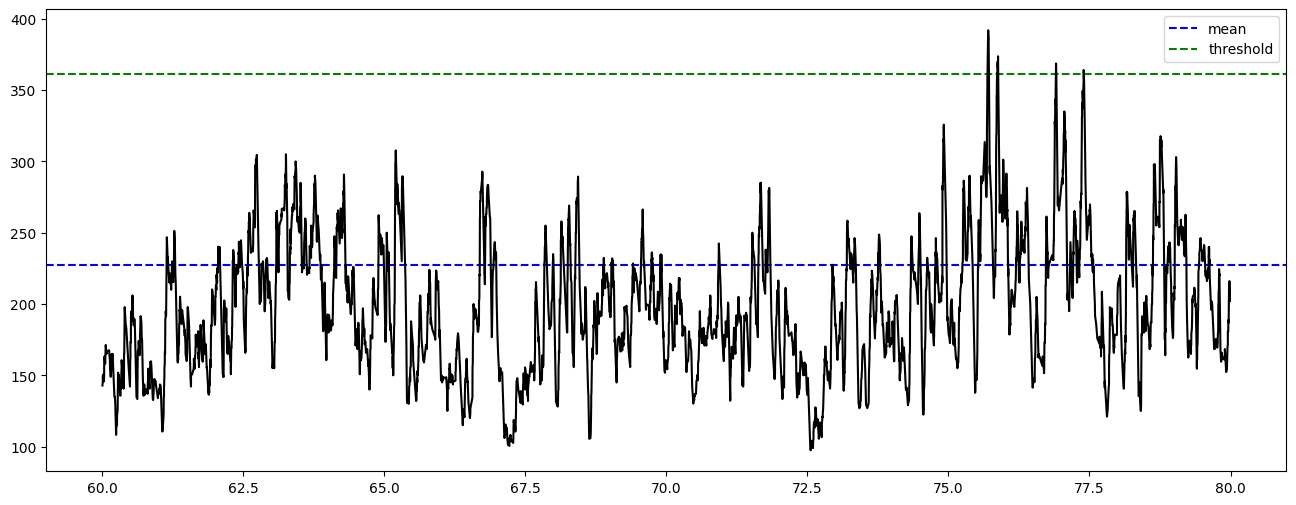

In [36]:
print(plot_window.start)
print(plot_window.stop)
mask = (collapsed_sim > plot_window.start) & (collapsed_sim < plot_window.stop)
collapsed_sim_plot = collapsed_sim[mask]
freq_ts_plot = freq_ts[mask]

fig, ax = plt.subplots(1,1, figsize=(16,6))
plt.plot(collapsed_sim_plot, freq_ts_plot, color='k')
plt.axhline(freq_ts.mean(), c="blue", ls="--", label="mean", zorder=-10)
plt.axhline(freq_ts.mean() + d*freq_ts.std(), c="green", ls="--", label="threshold", zorder=-10)
plt.legend()
plt.show()

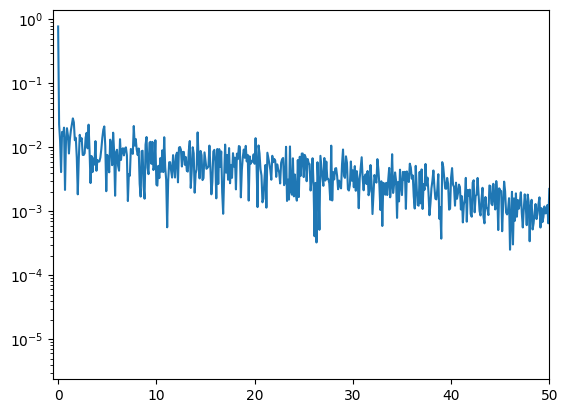

In [37]:
import scipy as sp
import scipy.fftpack

different_vals = np.diff(collapsed_sim, append=1) != 0
interp_fn = sp.interpolate.interp1d(collapsed_sim[different_vals], freq_ts[different_vals], kind='cubic', bounds_error=False, fill_value=0)
freq_ts_us = interp_fn(np.linspace(0, simulation_time, simulation_time*100))
# freq_ts_us /= np.sqrt(np.square(freq_ts_us).sum())
freq_ts_us /= np.max(freq_ts_us)
# plt.plot(freq_ts_us, color="black")

T = 1e-3
N = len(freq_ts_us)
yf = scipy.fftpack.fft(freq_ts_us)
xf = np.linspace(0, 1/(2*T), N//2)
plt.plot(xf, 2/N * np.abs(yf[:N//2]))
# plt.ylim((0, 100))
# plt.loglog()
plt.semilogy()
# plt.semilogx()
plt.xlim((-0.5,50))
# plt.xlim((-0.1,0.1))
plt.show()